# Spatial Correctness and Joint Air Pollution vs Bird Richness

This notebook analyzes bird richness with air-pollution variables jointly (not isolated one-by-one): Carbon_Mass, Dust_Mass, SO2_Mass, Sulfate_Mass, Sea_Salt_Mass, and Total_Aerosol_Extinction.

Scope:
- Spatial thinning: one record per (district, 5 km cell, species)
- Cell-level bird richness
- Joint multivariate pollution-richness model
- District-level pollution profile and richness patterns


In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.formula.api as smf

sns.set_theme(style="whitegrid", context="paper")
pd.set_option("display.max_columns", 120)
plt.rcParams["figure.dpi"] = 120
RANDOM_SEED = 42


## 1. Load bird + air pollution columns

In [2]:
candidate_paths = [
    Path("file6.csv"),
    Path("../file6.csv"),
    Path("../../file6.csv"),
    Path("final5.csv"),
    Path("../final5.csv"),
    Path("../../final5.csv"),
]

data_path = next((p for p in candidate_paths if p.exists()), None)
if data_path is None:
    raise FileNotFoundError("Could not find file6.csv or final5.csv from this notebook location.")

pollution_cols = [
    "Carbon_Mass",
    "Dust_Mass",
    "SO2_Mass",
    "Sulfate_Mass",
    "Sea_Salt_Mass",
    "Total_Aerosol_Extinction",
]

raw = pd.read_csv(data_path, low_memory=False)
required_cols = [
    "stateProvince",
    "verbatimScientificName",
    "decimalLatitude",
    "decimalLongitude",
    "eventDate",
] + pollution_cols

missing = [c for c in required_cols if c not in raw.columns]
if missing:
    raise ValueError(f"Missing required columns: {missing}")

df = raw[required_cols].copy()
df["eventDate"] = pd.to_datetime(df["eventDate"], errors="coerce")
for c in ["decimalLatitude", "decimalLongitude"] + pollution_cols:
    df[c] = pd.to_numeric(df[c], errors="coerce")

df["stateProvince"] = df["stateProvince"].astype(str).str.strip()
df["verbatimScientificName"] = df["verbatimScientificName"].astype(str).str.strip()

df = df.dropna(subset=[
    "stateProvince",
    "verbatimScientificName",
    "decimalLatitude",
    "decimalLongitude",
    "eventDate",
] + pollution_cols)

print(f"Using: {data_path.resolve()}")
print(f"Rows after cleaning: {len(df):,}")
print(f"Districts: {df['stateProvince'].nunique():,}")
print(f"Species: {df['verbatimScientificName'].nunique():,}")


Using: D:\maneesha\sem04\intro_DS\project\0020473-260226173443078\file6.csv
Rows after cleaning: 1,552,048
Districts: 25
Species: 429


## 2. Spatial thinning (district, 5 km cell, species)

In [3]:
def add_5km_grid(frame: pd.DataFrame) -> pd.DataFrame:
    out = frame.copy()
    lon0 = float(out["decimalLongitude"].median())
    lat0 = float(out["decimalLatitude"].median())
    lat_rad = np.radians(out["decimalLatitude"].to_numpy())
    out["x_km"] = (out["decimalLongitude"].to_numpy() - lon0) * 111.320 * np.cos(lat_rad)
    out["y_km"] = (out["decimalLatitude"].to_numpy() - lat0) * 110.574
    out["grid_x"] = np.floor(out["x_km"] / 5.0).astype(int)
    out["grid_y"] = np.floor(out["y_km"] / 5.0).astype(int)
    out["cell_id"] = (
        out["stateProvince"].astype(str)
        + "|"
        + out["grid_x"].astype(str)
        + "_"
        + out["grid_y"].astype(str)
    )
    return out

def thin_per_species_cell(frame: pd.DataFrame, seed: int = 42) -> pd.DataFrame:
    rng = np.random.default_rng(seed)
    work = frame.copy()
    work["_thin_key"] = (
        work["stateProvince"].astype(str)
        + "|"
        + work["grid_x"].astype(str)
        + "_"
        + work["grid_y"].astype(str)
        + "|"
        + work["verbatimScientificName"].astype(str)
    )
    work["_rand"] = rng.random(len(work))
    return (
        work.sort_values("_rand")
        .groupby("_thin_key", as_index=False)
        .head(1)
        .drop(columns=["_thin_key", "_rand"])
    )

df_grid = add_5km_grid(df)
df_thin = thin_per_species_cell(df_grid, seed=RANDOM_SEED)

print(f"Records before thinning: {len(df_grid):,}")
print(f"Records after thinning:  {len(df_thin):,}")
print(f"Retained fraction:       {len(df_thin)/len(df_grid):.2%}")


Records before thinning: 1,552,048
Records after thinning:  95,608
Retained fraction:       6.16%


## 3. Cell-level richness + joint pollution table

In [4]:
agg_dict = {"verbatimScientificName": "nunique"}
for c in pollution_cols:
    agg_dict[c] = "mean"

cell_summary = (
    df_thin.groupby(["stateProvince", "cell_id"], as_index=False)
    .agg(agg_dict)
    .rename(columns={"verbatimScientificName": "species_richness"})
)

cell_summary = cell_summary.dropna(subset=["species_richness"] + pollution_cols)

print(f"Cell rows for joint pollution analysis: {len(cell_summary):,}")
cell_summary.head(10)


Cell rows for joint pollution analysis: 1,740


,stateProvince,cell_id,species_richness,Carbon_Mass,Dust_Mass,SO2_Mass,Sulfate_Mass,Sea_Salt_Mass,Total_Aerosol_Extinction
0,Ampara,Ampara|14_13,19,4.011512e-10,2.650781e-09,2.008166e-09,1.951461e-09,1.612427e-08,0.129025
1,Ampara,Ampara|14_17,13,2.794967e-10,1.083189e-08,2.062002e-09,1.378525e-09,2.548921e-08,0.170013
2,Ampara,Ampara|15_15,47,3.071405e-10,1.597871e-08,1.983574e-09,1.398970e-09,2.068910e-08,0.144869
3,Ampara,Ampara|17_16,96,3.470856e-10,1.124547e-08,1.298726e-09,2.007004e-09,2.742852e-08,0.167653
4,Ampara,Ampara|17_17,1,4.828223e-10,1.082283e-09,2.481788e-10,2.971307e-09,3.468862e-08,0.173077
5,Ampara,Ampara|18_11,4,2.776719e-10,8.927480e-10,2.917934e-10,1.376158e-09,2.930091e-08,0.112756
6,Ampara,Ampara|19_12,5,2.464947e-10,9.682893e-09,2.089809e-09,1.180220e-09,1.768405e-08,0.124359
7,Ampara,Ampara|20_10,5,3.897739e-10,9.957822e-09,8.629496e-10,1.923504e-09,1.952652e-08,0.161312
8,Ampara,Ampara|20_14,26,3.931670e-10,6.045449e-09,1.106873e-09,1.753639e-09,2.812746e-08,0.200098
9,Ampara,Ampara|21_13,35,3.056344e-10,6.568205e-09,1.357029e-09,1.546063e-09,2.911968e-08,0.155092


## 4. Joint multivariate model: richness ~ all air-pollution variables

In [5]:
model_df = cell_summary.copy()

# z-score predictors so coefficients are comparable on a common scale.
for c in pollution_cols:
    mu = model_df[c].mean()
    sd = model_df[c].std(ddof=0)
    model_df[f"z_{c}"] = (model_df[c] - mu) / (sd if sd > 0 else 1.0)

z_cols = [f"z_{c}" for c in pollution_cols]
formula = "species_richness ~ " + " + ".join(z_cols)
fit = smf.ols(formula, data=model_df).fit()

print(fit.summary().tables[0])
print(fit.summary().tables[1])

rho, pval = stats.spearmanr(model_df["species_richness"], fit.fittedvalues)
print(f"Spearman(observed richness, fitted richness): r={rho:.3f}, p={pval:.3g}")


                            OLS Regression Results                            
Dep. Variable:       species_richness   R-squared:                       0.011
Model:                            OLS   Adj. R-squared:                  0.008
Method:                 Least Squares   F-statistic:                     3.296
Date:                Wed, 08 Apr 2026   Prob (F-statistic):            0.00315
Time:                        20:55:12   Log-Likelihood:                -9155.6
No. Observations:                1740   AIC:                         1.833e+04
Df Residuals:                    1733   BIC:                         1.836e+04
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                                 coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------
Intercept           

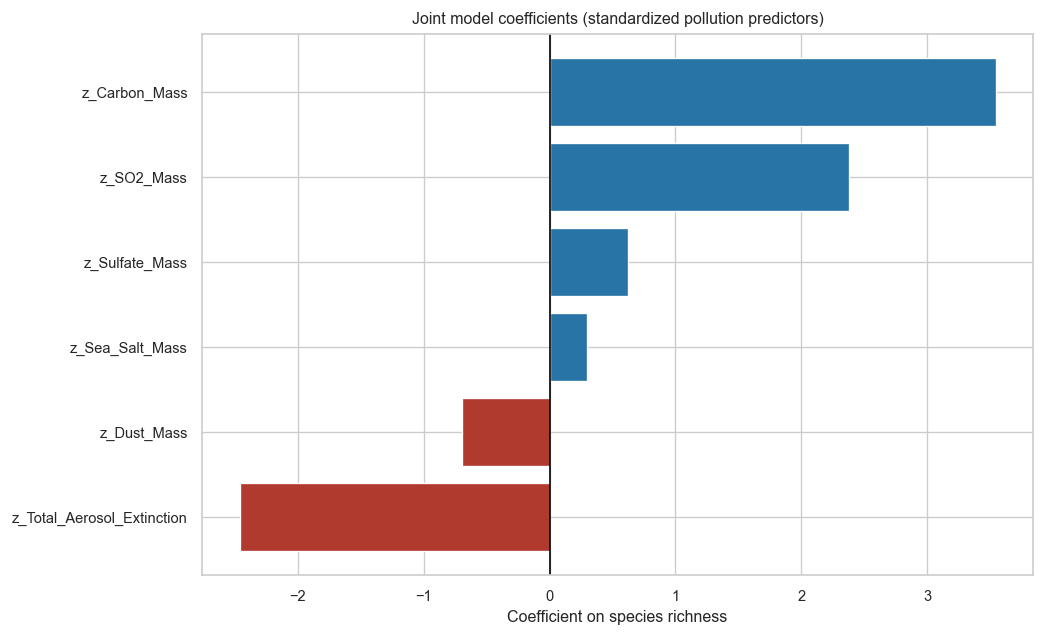

,term,coef,p_value
6,z_Total_Aerosol_Extinction,-2.462562,0.289416
2,z_Dust_Mass,-0.693614,0.719218
5,z_Sea_Salt_Mass,0.297443,0.847602
4,z_Sulfate_Mass,0.619797,0.839126
3,z_SO2_Mass,2.377485,0.089212
1,z_Carbon_Mass,3.543395,0.250963


In [6]:
coef_table = (
    fit.params.rename("coef").to_frame()
    .join(fit.pvalues.rename("p_value"))
    .reset_index()
    .rename(columns={"index": "term"})
)
coef_plot = coef_table[coef_table["term"].str.startswith("z_")].copy()
coef_plot = coef_plot.sort_values("coef")

plt.figure(figsize=(8.8, 5.4))
colors = ["#b03a2e" if x < 0 else "#2874a6" for x in coef_plot["coef"]]
plt.barh(coef_plot["term"], coef_plot["coef"], color=colors)
plt.axvline(0, color="black", linewidth=1)
plt.title("Joint model coefficients (standardized pollution predictors)")
plt.xlabel("Coefficient on species richness")
plt.tight_layout()
plt.show()

coef_plot


## 5. Joint pollution-richness structure visualizations

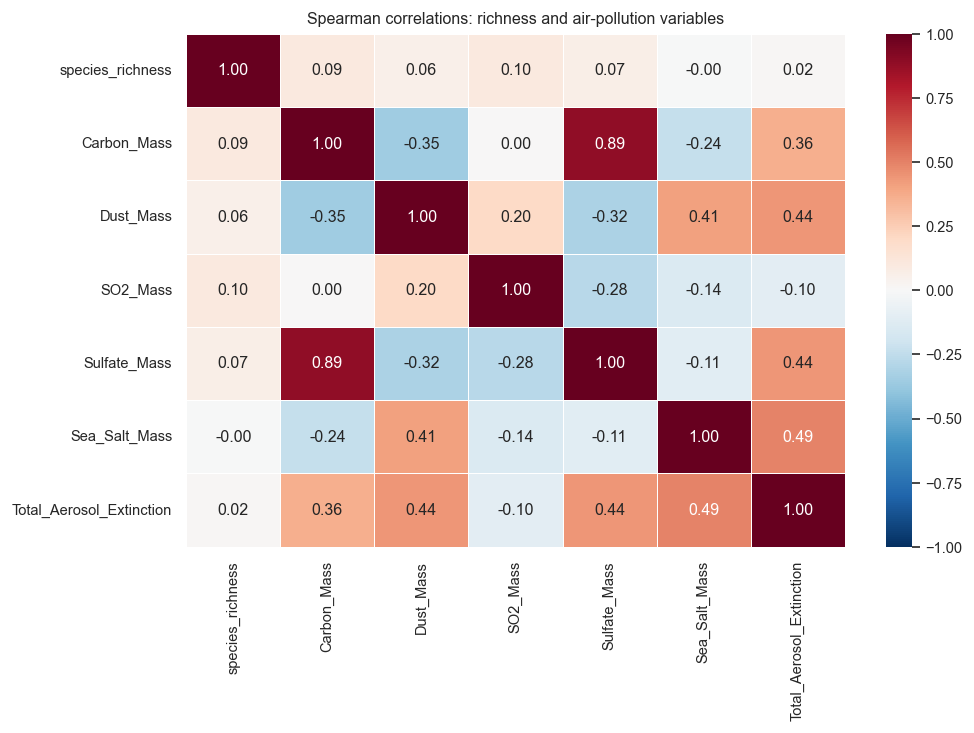

In [7]:
corr_df = cell_summary[["species_richness"] + pollution_cols].corr(method="spearman")

plt.figure(figsize=(8.6, 6.2))
sns.heatmap(corr_df, annot=True, fmt=".2f", cmap="RdBu_r", center=0, vmin=-1, vmax=1, linewidths=0.4)
plt.title("Spearman correlations: richness and air-pollution variables")
plt.tight_layout()
plt.show()


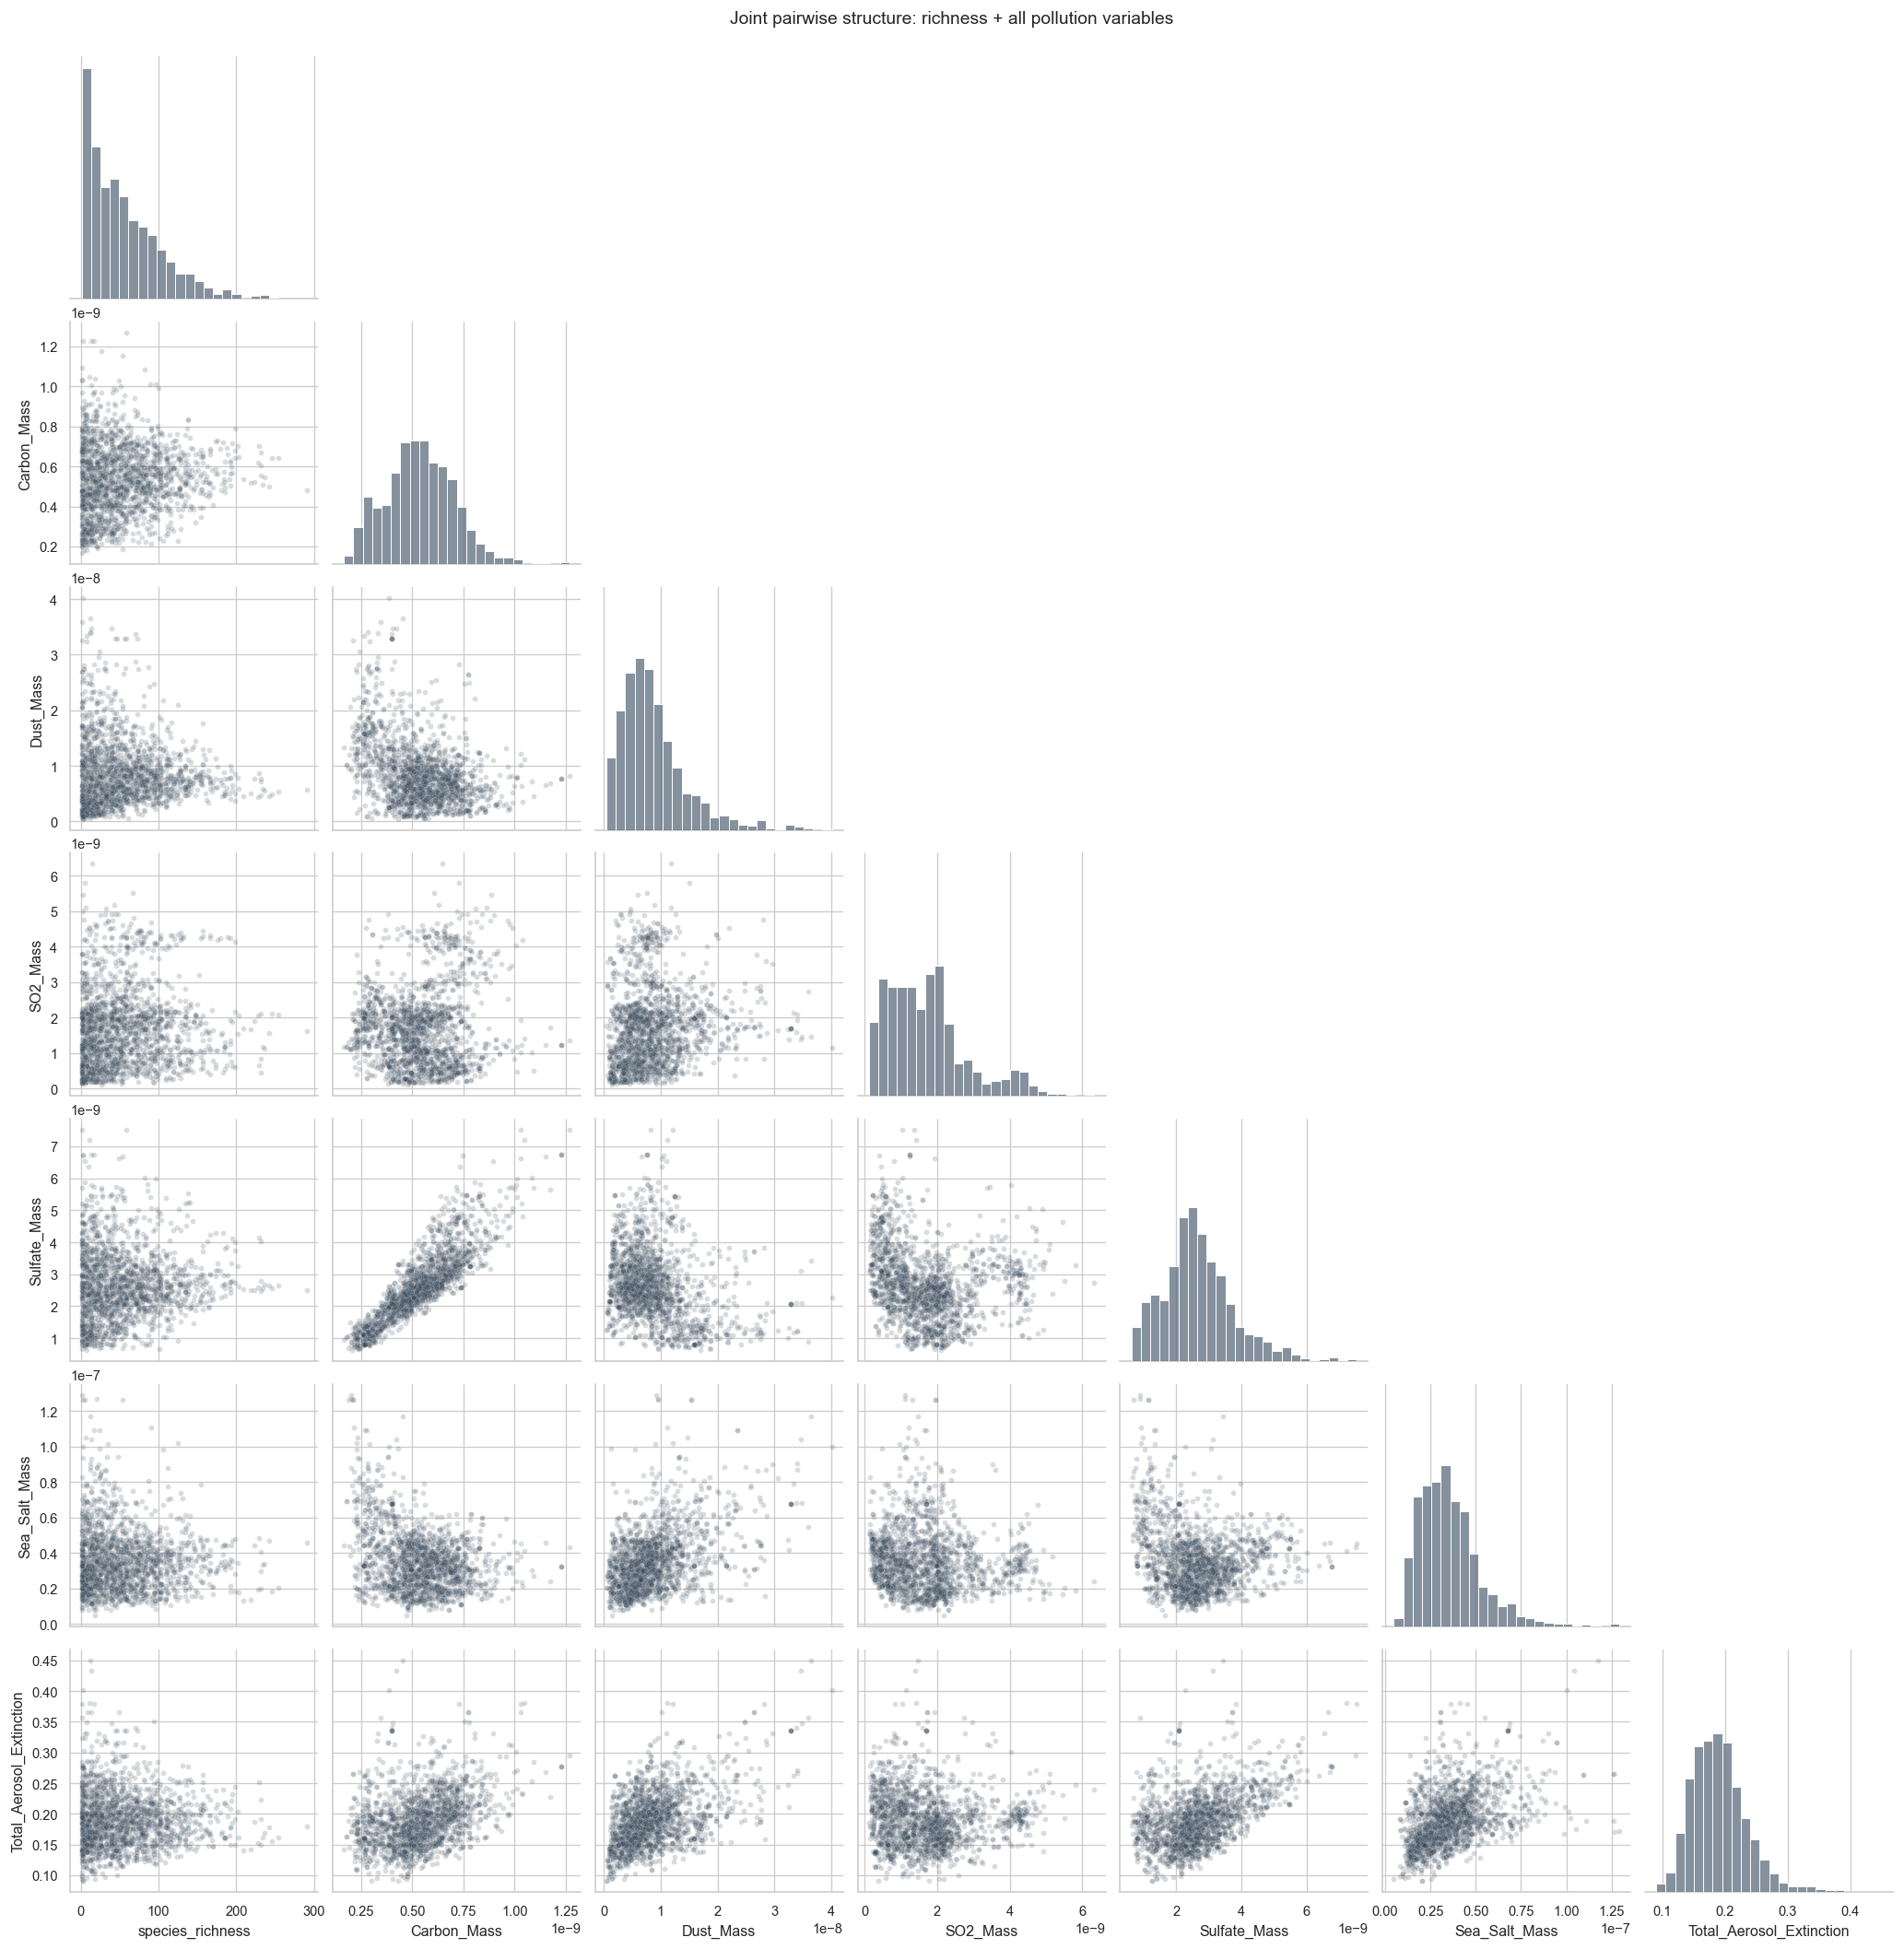

In [8]:
# Pairwise view keeps all pollution variables in one joint panel.
pair_cols = ["species_richness"] + pollution_cols
sample_n = min(3500, len(cell_summary))
pair_data = cell_summary[pair_cols].sample(sample_n, random_state=RANDOM_SEED)

g = sns.pairplot(
    pair_data,
    vars=pair_cols,
    corner=True,
    plot_kws={"alpha": 0.18, "s": 12, "color": "#2c3e50"},
    diag_kws={"bins": 24, "color": "#5d6d7e"},
)
g.fig.suptitle("Joint pairwise structure: richness + all pollution variables", y=1.01)
plt.show()


## 6. District-level joint pollution profile

,stateProvince,mean_cell_richness,Carbon_Mass,Dust_Mass,SO2_Mass,Sulfate_Mass,Sea_Salt_Mass,Total_Aerosol_Extinction,n_cells,z_Carbon_Mass,z_Dust_Mass,z_SO2_Mass,z_Sulfate_Mass,z_Sea_Salt_Mass,z_Total_Aerosol_Extinction
4,Colombo,84.769231,6.759217e-10,8.068938e-09,4.183789e-09,3.086572e-09,3.360565e-08,0.200789,39,1.698973,-0.519280,2.621898,0.627293,-0.345078,0.225961
7,Hambantota,80.955056,4.798541e-10,8.328672e-09,1.606101e-09,2.318867e-09,4.456278e-08,0.177518,89,-0.606952,-0.341287,-0.039384,-0.718168,0.685316,-0.609029
14,Mannar,80.740000,6.485268e-10,9.083041e-09,7.152088e-10,3.896274e-09,4.978484e-08,0.236205,50,1.376784,0.175678,-0.959167,2.046357,1.176391,1.496726
6,Gampaha,69.720588,6.292203e-10,8.073082e-09,3.866990e-09,2.756684e-09,3.506656e-08,0.195107,68,1.149724,-0.516440,2.294825,0.049139,-0.207695,0.022073
16,Matara,68.947368,5.109167e-10,8.102587e-09,2.026787e-09,2.316024e-09,4.287603e-08,0.182254,57,-0.241630,-0.496221,0.394945,-0.723152,0.526696,-0.439083
15,Matale,64.485294,4.980825e-10,8.924755e-09,1.481915e-09,2.442252e-09,2.722819e-08,0.178475,68,-0.392570,0.067206,-0.167597,-0.501927,-0.944805,-0.574698
17,Monaragala,59.850000,4.741106e-10,7.644935e-09,1.338365e-09,2.352747e-09,2.916859e-08,0.164964,100,-0.674501,-0.809846,-0.315802,-0.658792,-0.762332,-1.059500
21,Puttalam,59.247525,6.499246e-10,9.065542e-09,1.194500e-09,3.128319e-09,3.788811e-08,0.210904,101,1.393224,0.163686,-0.464333,0.700457,0.057639,0.588897
10,Kandy,58.507042,4.859285e-10,8.011124e-09,1.768553e-09,2.334338e-09,2.032852e-08,0.161409,71,-0.535513,-0.558900,0.128336,-0.691054,-1.593640,-1.187052
8,Jaffna,57.818182,6.611033e-10,1.171205e-08,7.307012e-10,4.240144e-09,5.218425e-08,0.248782,55,1.524695,1.977320,-0.943173,2.649016,1.402029,1.948029


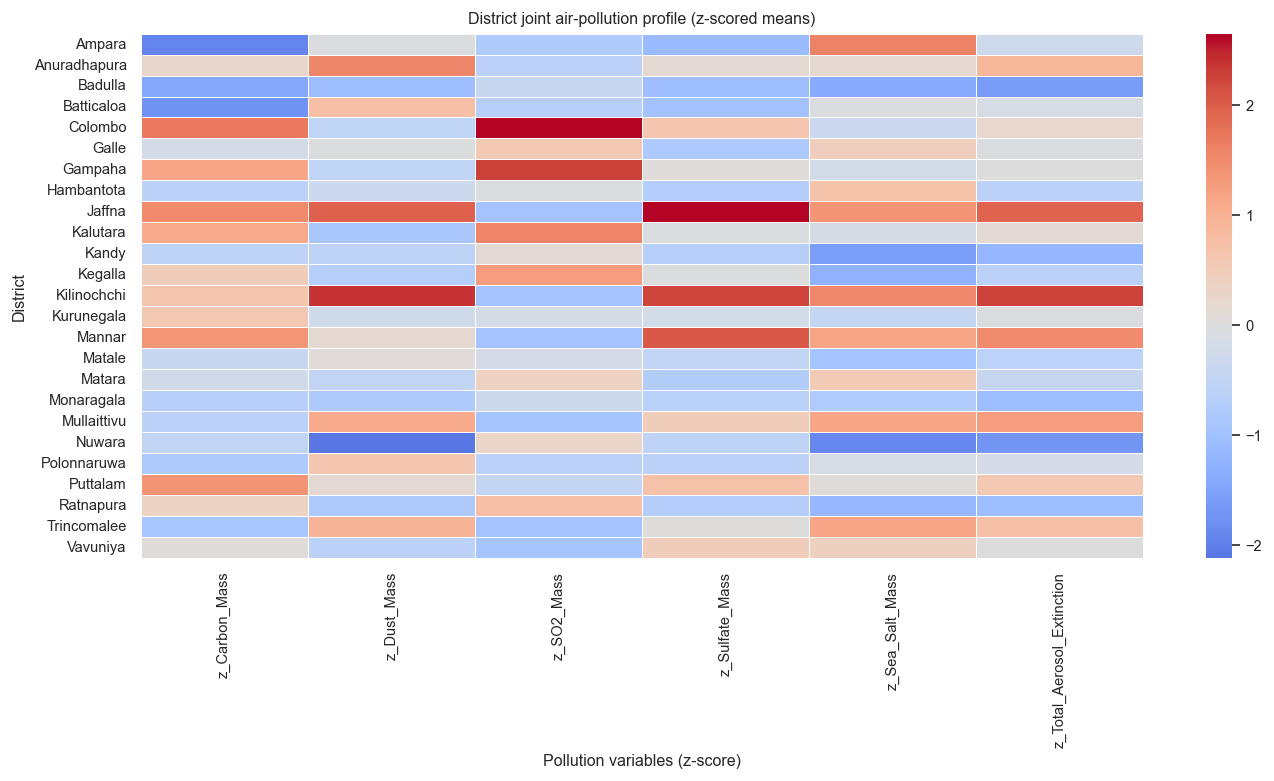

In [9]:
district_joint = (
    cell_summary.groupby("stateProvince", as_index=False)
    .agg({"species_richness": "mean", **{c: "mean" for c in pollution_cols}, "cell_id": "count"})
    .rename(columns={"species_richness": "mean_cell_richness", "cell_id": "n_cells"})
)

for c in pollution_cols:
    district_joint[f"z_{c}"] = (district_joint[c] - district_joint[c].mean()) / district_joint[c].std(ddof=0)

z_pollution_cols = [f"z_{c}" for c in pollution_cols]
profile = district_joint[["stateProvince"] + z_pollution_cols].set_index("stateProvince")

display(district_joint.sort_values("mean_cell_richness", ascending=False).head(30))

plt.figure(figsize=(11.8, 6.6))
sns.heatmap(profile, cmap="coolwarm", center=0, linewidths=0.4)
plt.title("District joint air-pollution profile (z-scored means)")
plt.xlabel("Pollution variables (z-score)")
plt.ylabel("District")
plt.tight_layout()
plt.show()


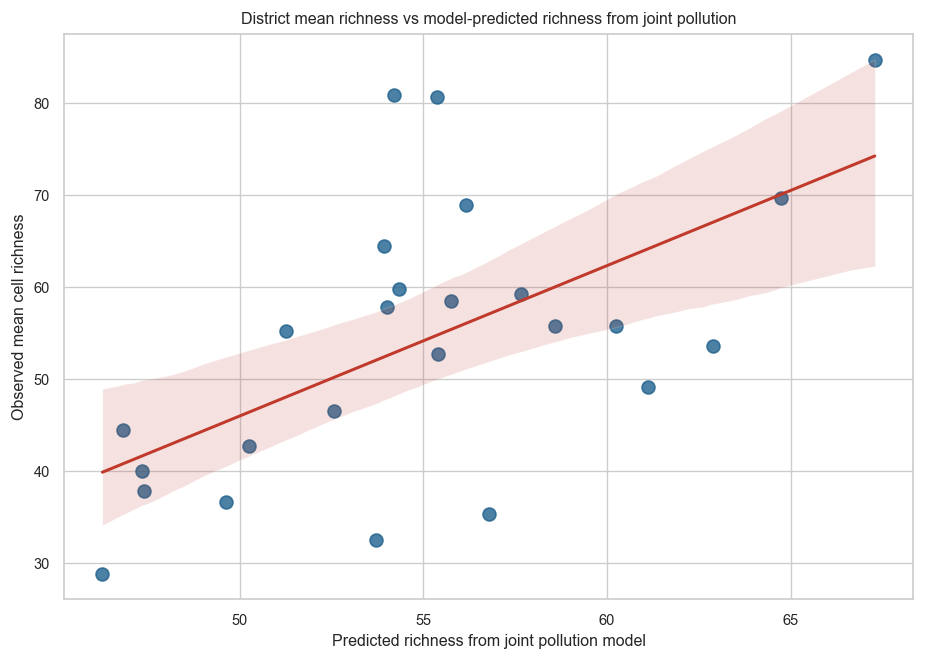

In [10]:
# Richness against combined pollution tendency from model predictions.
district_joint["pred_richness_from_pollution"] = fit.predict(
    district_joint.assign(**{f"z_{c}": district_joint[f"z_{c}"] for c in pollution_cols})
)

plt.figure(figsize=(7.8, 5.6))
sns.regplot(
    data=district_joint,
    x="pred_richness_from_pollution",
    y="mean_cell_richness",
    scatter_kws={"s": 60, "alpha": 0.8, "color": "#1f618d"},
    line_kws={"color": "#c0392b"},
)
plt.title("District mean richness vs model-predicted richness from joint pollution")
plt.xlabel("Predicted richness from joint pollution model")
plt.ylabel("Observed mean cell richness")
plt.tight_layout()
plt.show()


## 7. Optional exports

In [11]:
# Uncomment to export outputs.
# cell_summary.to_csv("air_pollution_cell_summary.csv", index=False)
# district_joint.to_csv("air_pollution_district_joint_summary.csv", index=False)
# coef_plot.to_csv("air_pollution_joint_model_coefficients.csv", index=False)
